In [2]:
import scanpy as sc
import squidpy as sq
import tangram as tg
import numpy as np

In [3]:
ad_sc = sc.read_h5ad('../data/linnarsson_adolescence_full.h5ad')
ad_sp = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '../data/linnarsson_adolescence_full.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [24]:
ad_sc.obs.Class.unique()

['Neurons', 'PeripheralGlia', 'Vascular', 'Oligos', 'Astrocytes', 'Ependymal', 'Immune']
Categories (7, object): ['Astrocytes', 'Ependymal', 'Immune', 'Neurons', 'Oligos', 'PeripheralGlia', 'Vascular']

In [25]:
sc.pp.normalize_total(ad_sc, target_sum=1e4)
sc.pp.normalize_total(ad_sp, target_sum=1e4)

In [26]:
ad_sc

AnnData object with n_obs × n_vars = 160796 × 27998
    obs: 'Class', 'region_macro'
    var: 'Accession', '_LogCV', '_LogMean', '_Selected', '_Total', '_Valid'

In [30]:
sc.pp.log1p(ad_sp)
sc.pp.log1p(ad_sc)

In [31]:
print(ad_sp.X.max())
print(ad_sc.X.max())

4.0463266
8.774567


In [32]:
tg.pp_adatas(ad_sc, ad_sp)


INFO:root:16562 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:16563 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [33]:
ad_map = tg.map_cells_to_space(
        ad_sc, 
        ad_sp,   
        num_epochs=300,
        mode='clusters',
        cluster_label='Class',
)

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 16562 genes and rna_count_based density_prior in clusters mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.346, KL reg: 0.168
Score: 0.470, KL reg: 0.000
Score: 0.470, KL reg: 0.000


INFO:root:Saving results..


In [34]:
import pandas as pd

In [35]:
ad_sp.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,sample,sample_id,n_genes,leiden,treatment,...,leiden_2,leiden_2.5,PIG_score,OLIG_score,leiden_0.1,leiden_0.2,leiden_0.3,re_annotation_regions,uniform_density,rna_count_based_density
AAACAAGTATCTCCCA-1-P24215_301,1,50,102,28217,34029,P24215_301,P24215_301,5333,6,BRICHOS,...,11,35,0.093254,0.006935,0,5,5,Olfactory areas,0.000039,0.000039
AAACAGAGCGACTCCT-1-P24215_301,1,14,94,10018,31732,P24215_301,P24215_301,3317,1,BRICHOS,...,17,7,0.374221,1.611454,3,2,3,Hypothalamus,0.000039,0.000033
AAACCGGGTAGGTACC-1-P24215_301,1,42,28,24142,12539,P24215_301,P24215_301,4982,0,BRICHOS,...,1,14,0.229887,0.858781,0,1,1,Supragranualar layers,0.000039,0.000038
AAACCGTTCGTCCAGG-1-P24215_301,1,52,42,29202,16598,P24215_301,P24215_301,6046,0,BRICHOS,...,0,11,0.012875,0.548931,0,3,2,Infragranular layers,0.000039,0.000040
AAACCTCATGAAGTTG-1-P24215_301,1,37,19,21611,9928,P24215_301,P24215_301,6179,0,BRICHOS,...,1,14,0.076070,0.235175,0,1,1,Supragranualar layers,0.000039,0.000041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTCAGTGTGCTAC-1-P28052_203,1,24,64,15524,23040,P28052_203,P28052_203,7233,4,PBS,...,41,37,0.145172,1.043804,1,0,0,Caudoputamen,0.000039,0.000043
TTGTTGTGTGTCAAGA-1-P28052_203,1,31,77,19072,26813,P28052_203,P28052_203,7315,4,PBS,...,41,37,0.225508,0.990587,1,0,0,Caudoputamen,0.000039,0.000043
TTGTTTCATTAGTCTA-1-P28052_203,1,60,30,33717,13124,P28052_203,P28052_203,6504,1,PBS,...,5,15,0.168308,0.581865,3,2,3,Hypothalamus,0.000039,0.000042
TTGTTTCCATACAACT-1-P28052_203,1,45,27,26128,12265,P28052_203,P28052_203,5322,1,PBS,...,17,27,0.307190,0.876207,3,2,3,Hypothalamus,0.000039,0.000039


In [36]:
tg.project_cell_annotations(ad_map, ad_sp, annotation='Class')
annotation_list = list(pd.unique(ad_sc.obs['Class']))

INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


In [50]:
ad_sp.obsm["tangram_ct_pred"]

,Neurons,Oligos,Astrocytes,Vascular,PeripheralGlia,Immune,Ependymal
AAACAAGTATCTCCCA-1-P24215_301,0.000048,0.000021,0.000039,0.000044,0.000032,0.000016,1.147253e-05
AAACAGAGCGACTCCT-1-P24215_301,0.000024,0.000040,0.000040,0.000052,0.000034,0.000038,3.515547e-06
AAACCGGGTAGGTACC-1-P24215_301,0.000036,0.000042,0.000039,0.000012,0.000082,0.000029,1.443868e-06
AAACCGTTCGTCCAGG-1-P24215_301,0.000046,0.000042,0.000032,0.000036,0.000039,0.000016,7.507185e-07
AAACCTCATGAAGTTG-1-P24215_301,0.000047,0.000033,0.000031,0.000037,0.000036,0.000053,5.355012e-06
...,...,...,...,...,...,...,...
TTGTTCAGTGTGCTAC-1-P28052_203,0.000046,0.000045,0.000034,0.000036,0.000046,0.000031,3.474503e-05
TTGTTGTGTGTCAAGA-1-P28052_203,0.000045,0.000041,0.000045,0.000037,0.000038,0.000038,2.680491e-05
TTGTTTCATTAGTCTA-1-P28052_203,0.000047,0.000032,0.000043,0.000033,0.000054,0.000020,8.541191e-05
TTGTTTCCATACAACT-1-P28052_203,0.000037,0.000035,0.000052,0.000028,0.000043,0.000056,2.276838e-05


In [52]:
df = ad_sp.obsm["tangram_ct_pred"]              # spots × classes (probabilities)


In [53]:
row_sums = df.sum(axis=1)
df_norm = df.div(row_sums.replace(0, np.nan), axis=0).fillna(0.0)

# now rows sum to 1
assert np.allclose(df_norm.sum(axis=1).to_numpy(), 1.0, atol=1e-6)

In [56]:
calls = df_norm.idxmax(axis=1)

In [58]:
calls.value_counts()

Neurons           5353
Immune            4555
Vascular          3810
Astrocytes        3732
Oligos            3205
Ependymal         2880
PeripheralGlia    2125
Name: count, dtype: int64

In [62]:
ad_sp.obs['call'] = ad_sp.obs.index.map(calls)

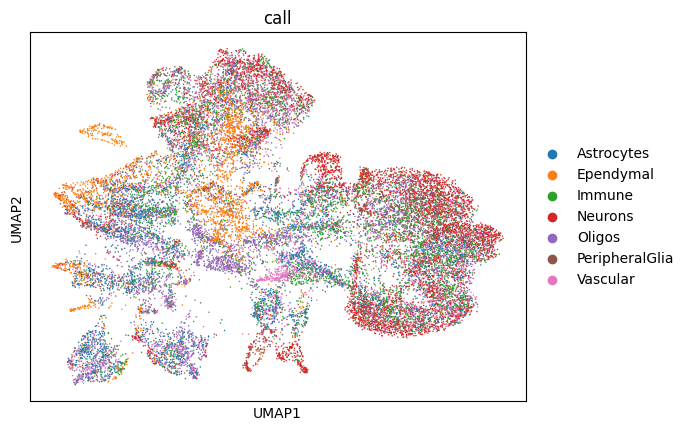

In [63]:
sc.pl.umap(ad_sp, color = 'call')

In [ ]:
calls = df_grp.idxmax(axis=1)
pmax  = df_grp.max(axis=1)
ad_sp.obs["tg_call"]  = pd.Categorical(calls)
ad_sp.obs["tg_pmax"]  = pmax

In [54]:
df_norm

,Neurons,Oligos,Astrocytes,Vascular,PeripheralGlia,Immune,Ependymal
AAACAAGTATCTCCCA-1-P24215_301,0.227891,0.099460,0.184206,0.207134,0.152598,0.074596,0.054115
AAACAGAGCGACTCCT-1-P24215_301,0.105750,0.173083,0.172040,0.224337,0.146707,0.162883,0.015200
AAACCGGGTAGGTACC-1-P24215_301,0.148059,0.174459,0.163392,0.048063,0.340982,0.119027,0.006019
AAACCGTTCGTCCAGG-1-P24215_301,0.215476,0.200985,0.149057,0.172574,0.184226,0.074131,0.003551
AAACCTCATGAAGTTG-1-P24215_301,0.194069,0.136646,0.127416,0.153139,0.147424,0.219100,0.022207
...,...,...,...,...,...,...,...
TTGTTCAGTGTGCTAC-1-P28052_203,0.168122,0.164102,0.125645,0.132278,0.169686,0.113008,0.127159
TTGTTGTGTGTCAAGA-1-P28052_203,0.166593,0.152073,0.166217,0.135571,0.140228,0.140720,0.098597
TTGTTTCATTAGTCTA-1-P28052_203,0.149882,0.102341,0.136010,0.105528,0.170228,0.064976,0.271036
TTGTTTCCATACAACT-1-P28052_203,0.135114,0.128574,0.189258,0.102127,0.157655,0.204544,0.082728


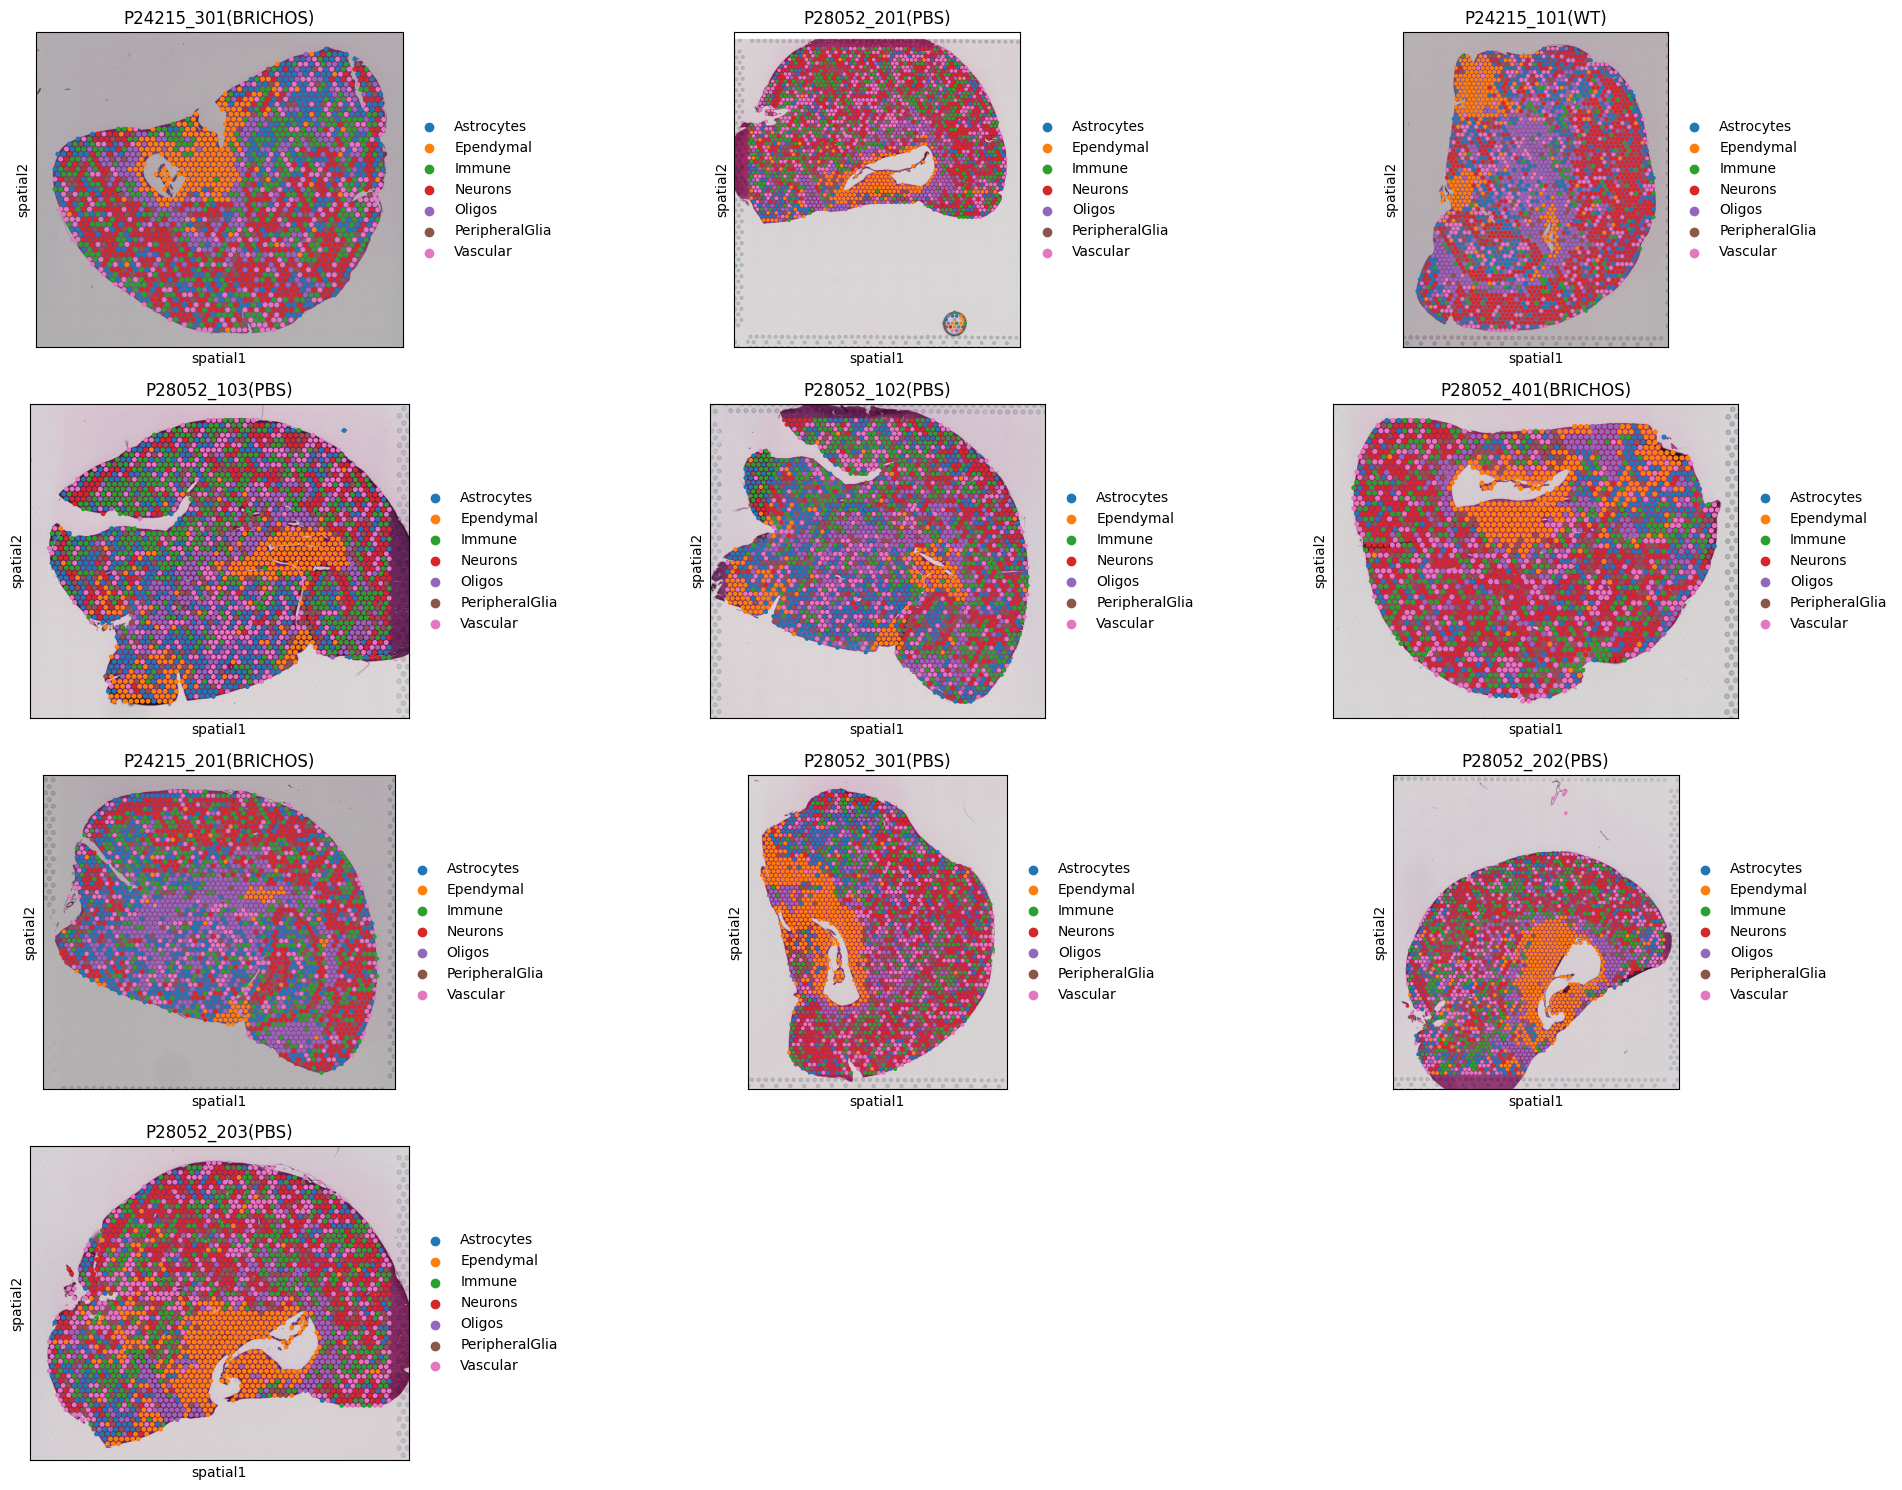

In [68]:
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))
from analysis_utils import (
    volcano_plot_br,
    plot_spatial_clusters_per_sample,
    plot_dotplot_by_treatment,
    plot_relative_cluster_composition,
    score_and_plot_modules
)
plot_spatial_clusters_per_sample(ad_sp, color = 'call', figsize=(20,15))

In [38]:
import numpy as np
import scanpy as sc

def plot_cell_annotation_sc_with_library(
    adata_sp,
    annotation_list,
    *,
    library_id=None,        # e.g. "P24215_101"
    library_col=None,       # e.g. "sample_id" if each cell has its library label
    x="x",
    y="y",
    spot_size=None,
    scale_factor=None,
    perc=0,
    alpha_img=1.0,
    bw=False,
    ax=None,
):
    """
    Drop-in replacement for tg.plot_cell_annotation_sc with support for multi-library AnnData.
    """

    # Clean previous columns
    adata_sp.obs.drop(annotation_list, inplace=True, errors="ignore", axis=1)

    # Build obs columns from obsm["tangram_ct_pred"]
    if "tangram_ct_pred" not in adata_sp.obsm:
        raise KeyError("adata_sp.obsm['tangram_ct_pred'] not found.")
    df = adata_sp.obsm["tangram_ct_pred"][annotation_list]
    # --- construct_obs_plot(df, adata_sp, perc=perc) inline ---
    # keep top-`perc` percentile if desired (perc=0 keeps all)
    if perc and perc > 0:
        thr = np.nanpercentile(df.values, 100 - perc, axis=0)
        df = df.where(df.ge(thr, axis=1), other=np.nan)
    for col in df.columns:
        adata_sp.obs[col] = df[col].values

    # Decide plotting path
    has_uns_spatial = "spatial" in adata_sp.uns and isinstance(adata_sp.uns["spatial"], dict)

    # Case A: Visium-style with .uns['spatial'] present -> must specify library
    if has_uns_spatial:
        if library_id is None:
            # Try to infer from a per-cell column if provided
            if library_col is not None and library_col in adata_sp.obs:
                vals = adata_sp.obs[library_col].astype(str).unique().tolist()
                if len(vals) == 1:
                    library_id = vals[0]
                else:
                    raise ValueError(
                        "Found multiple libraries in `.uns['spatial']` and multiple values in "
                        f"obs['{library_col}'] ({vals}). Please pass library_id='...'. "
                        f"Options in uns['spatial']: {list(adata_sp.uns['spatial'].keys())}"
                    )
            else:
                raise ValueError(
                    "Found multiple libraries in `.uns['spatial']`. Please pass library_id='...'. "
                    f"Options: {list(adata_sp.uns['spatial'].keys())}"
                )

        # Rules from original Tangram function
        if spot_size is not None and scale_factor is not None:
            raise ValueError("Spot Size and Scale Factor should be None when ad_sp.uns['spatial'] exists")

        sc.pl.spatial(
            adata_sp,
            color=annotation_list,
            library_id=library_id,    # <-- the missing piece
            cmap="viridis",
            show=False,
            frameon=False,
            spot_size=spot_size,
            scale_factor=scale_factor,
            alpha_img=alpha_img,
            bw=bw,
            ax=ax,
        )

    # Case B: No Visium mapping in .uns -> fall back to coordinates
    else:
        # If there are no spatial coords in .obsm, build them from obs[x], obs[y]
        if "spatial" not in adata_sp.obsm:
            if (x not in adata_sp.obs) or (y not in adata_sp.obs):
                raise KeyError(
                    "No .uns['spatial'] and .obsm['spatial'] missing. "
                    f"Provide obs columns x='{x}' and y='{y}' or supply a Visium .uns['spatial']."
                )
            coords = np.column_stack([adata_sp.obs[x].to_numpy(), adata_sp.obs[y].to_numpy()])
            adata_sp.obsm["spatial"] = coords.astype(float)

        if spot_size is None and scale_factor is None:
            raise ValueError(
                "Spot Size and Scale Factor cannot be None when ad_sp.uns['spatial'] does not exist"
            )

        sc.pl.spatial(
            adata_sp,
            color=annotation_list,
            cmap="viridis",
            show=False,
            frameon=False,
            spot_size=spot_size,
            scale_factor=scale_factor,
            alpha_img=alpha_img,
            bw=bw,
            ax=ax,
        )

    # cleanup
    adata_sp.obs.drop(annotation_list, inplace=True, errors="ignore", axis=1)

In [51]:
for sam in ad_sp.obs.sample_id.unique():
    plot_cell_annotation_sc_with_library(
        ad_sp[ad_sp.obs.sample_id == sam].copy(),
        annotation_list,
        library_id=sam,   
        spot_size=100
    )

Error in callback <function _draw_all_if_interactive at 0x36ea0c5e0> (for post_execute):



KeyboardInterrupt



Error in callback <function flush_figures at 0x358380820> (for post_execute):


KeyboardInterrupt: 